# MS lesion segmentation — benchmark

**Author:** micmas (Neurodesk MS Workshop)

**Date:** June 2026

**License:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

---

Companion to `ms_workshop.ipynb`. This notebook **scans the results folder, finds every subject that already has SAMSEG and/or LST-AI output**, scores each against the expert consensus mask (Dice), and summarises the comparison.

It runs **no processing** — it only reads results produced by the main notebook, so it is fast. Point `WORK` at the folder that holds your `derivatives/` (e.g. the shared teaching folder).

## Table of contents
[1. Setup](#1.-Setup)  
[2. Discover and score](#2.-Discover-all-processed-subjects-and-score-them)  
[3. Summary](#3.-Summary-and-comparison)  
[4. Detection by lesion size](#4.-Detection-by-lesion-size)  
[5. Clinical scores](#5.-Add-clinical-scores-(optional))  

## 1. Setup

In [1]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from IPython.display import display
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', message='.*no sform.*')

# ============================ Configuration ============================
#WORK = Path('/home/jovyan/neurodesktop-storage/neurodesk-ms-workshop')
WORK = Path('/data/teaching/micmas/neurodesk-ms-workshop')   # pre-processed teaching folder

DATA = WORK / 'open_ms_data'     # holds the expert masks
OUT  = WORK / 'derivatives'      # holds SAMSEG / LST-AI results
print('WORK:', WORK); print('DATA:', DATA); print('OUT :', OUT)

# --- helpers ---------------------------------------------------------------
def grab(folder, *keys):
    for f in sorted(Path(folder).glob('*.nii.gz')):
        n = f.name.lower()
        if all(k in n for k in keys):
            return f
    return None

def find_gt_for(name):
    # locate the expert consensus mask for a subject across the dataset roots
    cs = DATA / 'cross_sectional'
    for root in [cs/'coregistered_resampled', cs/'coregistered', cs]:
        d = root / name
        if d.is_dir():
            gt = (grab(d,'consensus') or grab(d,'gold') or grab(d,'lesion')
                  or grab(d,'gt') or grab(d,'mask'))
            if gt:
                return gt
    return None

def dice(a, b):
    inter = np.logical_and(a, b).sum(); denom = a.sum() + b.sum()
    return 2.0 * inter / denom if denom else float('nan')

def metrics(mask_img, gt_img, gt_d):
    native = mask_img.get_fdata() > 0
    vox = float(np.prod(mask_img.header.get_zooms()[:3]))
    vol_ml = native.sum() * vox / 1000.0
    in_gt = resample_to_img(mask_img, gt_img, interpolation='nearest').get_fdata() > 0
    return round(dice(in_gt, gt_d), 3), round(vol_ml, 1)

# extras for the size + clinical analyses
import importlib, sys, subprocess
for pkg in ['scipy', 'pyreadr']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
from scipy import ndimage

print('Setup complete.')

WORK: /data/teaching/micmas/neurodesk-ms-workshop
DATA: /data/teaching/micmas/neurodesk-ms-workshop/open_ms_data
OUT : /data/teaching/micmas/neurodesk-ms-workshop/derivatives
Setup complete.


## 2. Discover all processed subjects and score them

In [2]:
# Build the SAMSEG / LST-AI lesion masks from whatever each subject folder contains.
def samseg_mask(subj_out):
    les = subj_out / 'samseg' / 'lesions.nii.gz'
    if les.exists():
        return nib.load(str(les))
    seg = subj_out / 'samseg' / 'seg.mgz'           # derive lesion label (99) directly, no FreeSurfer needed
    if seg.exists():
        s = nib.load(str(seg))
        return nib.Nifti1Image((s.get_fdata() == 99).astype('uint8'), s.affine, s.header)
    return None

def lstai_mask(subj_out):
    d = subj_out / 'lst_ai'
    if not d.is_dir():
        return None
    p = grab(d, 'seg') or grab(d, 'lesion') or next(iter(sorted(d.glob('*.nii.gz'))), None)
    return nib.load(str(p)) if p else None

records = []
for subj_out in sorted(p for p in OUT.iterdir() if p.is_dir()):
    name = subj_out.name
    gt = find_gt_for(name)
    if gt is None:
        continue                                    # no expert mask -> can't score
    gt_img = nib.load(str(gt)); gt_d = gt_img.get_fdata() > 0
    vox = float(np.prod(gt_img.header.get_zooms()[:3]))
    row = {'id': name, 'expert_ml': round(gt_d.sum() * vox / 1000.0, 1)}

    sam = samseg_mask(subj_out)
    if sam is not None:
        row['SAMSEG_dice'], row['SAMSEG_ml'] = metrics(sam, gt_img, gt_d)
    lst = lstai_mask(subj_out)
    if lst is not None:
        row['LST-AI_dice'], row['LST-AI_ml'] = metrics(lst, gt_img, gt_d)

    if 'SAMSEG_dice' in row or 'LST-AI_dice' in row:
        records.append(row)

bench = pd.DataFrame(records).sort_values('id').reset_index(drop=True)
print(f'Found {len(bench)} subject(s) with results in {OUT}')
bench

Found 6 subject(s) with results in /data/teaching/micmas/neurodesk-ms-workshop/derivatives


,id,expert_ml,SAMSEG_dice,SAMSEG_ml,LST-AI_dice,LST-AI_ml
0,patient01,31.4,0.498,13.8,0.718,24.1
1,patient02,1.4,0.333,0.3,0.580,0.7
2,patient03,1.1,0.005,0.0,0.571,0.6
3,patient04,40.4,0.449,13.8,0.799,33.7
4,patient05,30.1,0.674,15.6,0.880,25.1
5,patient07,1.3,0.410,0.5,0.628,1.0


## 3. Summary and comparison

           SAMSEG  LST-AI
mean Dice   0.395   0.696
sd          0.223   0.125
n           6.000   6.000


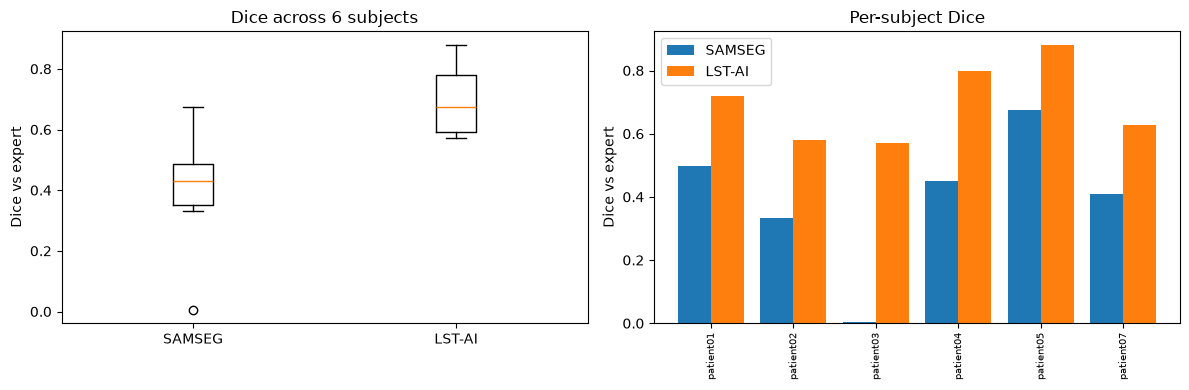

In [3]:
methods = [m for m in ['SAMSEG', 'LST-AI'] if f'{m}_dice' in bench.columns]

summary = pd.DataFrame(
    {m: [bench[f'{m}_dice'].mean(), bench[f'{m}_dice'].std(), bench[f'{m}_dice'].count()] for m in methods},
    index=['mean Dice', 'sd', 'n']
).round(3)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# boxplot of Dice per method
axes[0].boxplot([bench[f'{m}_dice'].dropna() for m in methods])
axes[0].set_xticks(range(1, len(methods) + 1)); axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Dice vs expert'); axes[0].set_title(f'Dice across {len(bench)} subjects')

# per-subject grouped bars
x = np.arange(len(bench)); w = 0.8 / max(len(methods), 1)
for k, m in enumerate(methods):
    axes[1].bar(x + (k - (len(methods) - 1) / 2) * w, bench[f'{m}_dice'], width=w, label=m)
axes[1].set_xticks(x); axes[1].set_xticklabels(bench['id'], rotation=90, fontsize=7)
axes[1].set_ylabel('Dice vs expert'); axes[1].legend(); axes[1].set_title('Per-subject Dice')

plt.tight_layout(); plt.show()

## 4. Detection by lesion size

Overall Dice hides an important effect: **small lesions are much harder to segment than large ones**. Here we label each lesion in the expert mask as a separate connected component, sort them into size categories, and measure each method's **detection rate** per category — a lesion counts as detected if at least 10% of its voxels fall inside the prediction. This mirrors the lesion-by-volume analysis used in MS segmentation benchmarks.

Expert lesions per size category:
size
small\n(<0.02 mL)        962
medium\n(0.02-0.1 mL)    448
large\n(>0.1 mL)         194

Detection rate (fraction of expert lesions detected):
size    small\n(<0.02 mL)  medium\n(0.02-0.1 mL)  large\n(>0.1 mL)
method                                                            
LST-AI               0.14                   0.80              0.90
SAMSEG               0.02                   0.11              0.43


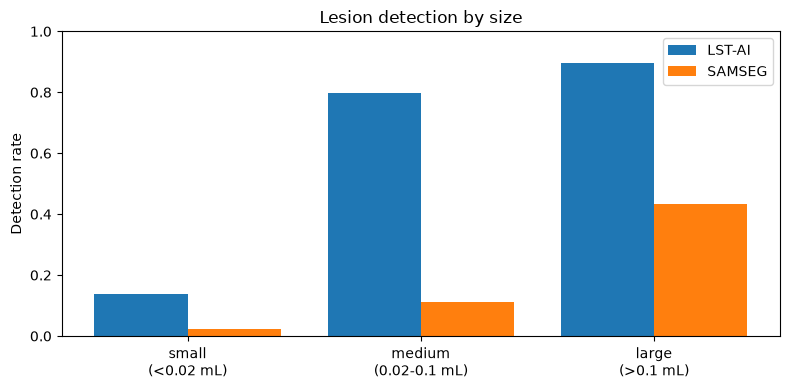

In [4]:
# Individual-lesion size categories (volume of each connected component, in mL)
SIZE_BINS   = [0, 0.02, 0.1, np.inf]
SIZE_LABELS = ['small\n(<0.02 mL)', 'medium\n(0.02-0.1 mL)', 'large\n(>0.1 mL)']
DETECT_FRAC = 0.10   # an expert lesion is "detected" if >=10% of its voxels fall in the prediction

def lesionwise(subj_out, name):
    gt = find_gt_for(name)
    if gt is None:
        return []
    gt_img = nib.load(str(gt)); gt_d = gt_img.get_fdata() > 0
    vox = float(np.prod(gt_img.header.get_zooms()[:3]))
    lab, nles = ndimage.label(gt_d)
    preds = {}
    for m, img in [('SAMSEG', samseg_mask(subj_out)), ('LST-AI', lstai_mask(subj_out))]:
        if img is not None:
            preds[m] = resample_to_img(img, gt_img, interpolation='nearest').get_fdata() > 0
    rows = []
    for k in range(1, nles + 1):
        comp = lab == k
        vol_ml = comp.sum() * vox / 1000.0
        size = SIZE_LABELS[int(np.digitize(vol_ml, SIZE_BINS)) - 1]
        for m, pred in preds.items():
            frac = np.logical_and(comp, pred).sum() / comp.sum()
            rows.append({'id': name, 'method': m, 'lesion_ml': vol_ml,
                         'size': size, 'detected': frac >= DETECT_FRAC})
    return rows

det = pd.DataFrame([r for so in sorted(p for p in OUT.iterdir() if p.is_dir())
                    for r in lesionwise(so, so.name)])

counts = det.groupby('size')['lesion_ml'].count().reindex(SIZE_LABELS)
rate   = (det.groupby(['method', 'size'])['detected'].mean()
          .unstack().reindex(columns=SIZE_LABELS))
print('Expert lesions per size category:'); print(counts.to_string())
print('\nDetection rate (fraction of expert lesions detected):'); print(rate.round(2).to_string())

methods = list(rate.index)
x = np.arange(len(SIZE_LABELS)); w = 0.8 / max(len(methods), 1)
fig, ax = plt.subplots(figsize=(8, 4))
for k, m in enumerate(methods):
    ax.bar(x + (k - (len(methods) - 1) / 2) * w, rate.loc[m].values, width=w, label=m)
ax.set_xticks(x); ax.set_xticklabels(SIZE_LABELS)
ax.set_ylabel('Detection rate'); ax.set_ylim(0, 1)
ax.set_title('Lesion detection by size'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Add clinical scores (optional)

In [5]:
# Join the clinical data shipped with the dataset (age, sex, MS type, EDSS).
out_csv = OUT / 'benchmark.csv'
demog_path = DATA / 'cs_demog.rda'
if demog_path.exists():
    import pyreadr
    demog = pyreadr.read_r(str(demog_path))['cs_demog']
    table = bench.merge(demog, on='id', how='left')
else:
    print('cs_demog.rda not found — saving the Dice table without clinical data.')
    table = bench

display(table)
table.to_csv(out_csv, index=False)
print('Saved', out_csv)

,id,expert_ml,SAMSEG_dice,SAMSEG_ml,LST-AI_dice,LST-AI_ml,age,sex,ms_type,edss,criteria
0,patient01,31.4,0.498,13.8,0.718,24.1,31.0,F,RR,1.5,McDonald 2010
1,patient02,1.4,0.333,0.3,0.580,0.7,33.0,M,CIS,0.0,McDonald 2010
2,patient03,1.1,0.005,0.0,0.571,0.6,37.0,F,NaN,NaN,NaN
3,patient04,40.4,0.449,13.8,0.799,33.7,25.0,M,SP,6.5,McDonald 2005
4,patient05,30.1,0.674,15.6,0.880,25.1,33.0,F,RR,3.5,McDonald 2005
5,patient07,1.3,0.410,0.5,0.628,1.0,53.0,F,RR,0.5,McDonald 2010


Saved /data/teaching/micmas/neurodesk-ms-workshop/derivatives/benchmark.csv
